### Perform this filtering, as described from the SCENIC+ methods section

“To ensure high-confidence eRegulons, we required concordance between TF expression and chromatin-based regulon activity. We therefore retained only eRegulons whose region AUC scores strongly correlated with TF expression at the cell-type level, after noise reduction via semi-pseudobulking.”

TF-to-gene relationship, then	region-to-gene relationship
- positive (+)	positive (+)	TF opens chromatin and activates gene expression
- positive (+)	negative (-)	When the TF is expressed the target gene is also expressed but the regions linked to the gene are closed.
- negative (-)	positive (+)	When the TF is expressed the target gene is not expressed. When the target gene is expressed, regions linked to this gene are open. TF could be a chromatin closing repressor.
- negative (-)	negative (-)	When the TF is expressed the target gene is not expressed. When the target gene is expressed, regions linked to this gene are closed.

In [22]:
import pandas as pd 
import numpy as np
import scanpy as sc
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [23]:
plots_dir = "regulon_volcano_plots/"

In [2]:
%%time
AUC_df = pd.read_csv("04A_regulon_AUC_df.csv", index_col = 0)

CPU times: user 2.35 s, sys: 303 ms, total: 2.65 s
Wall time: 2.65 s


In [3]:
%%time
RNA_adata = sc.read_h5ad("03_RNA_adata_for_scenicplus.h5ad")

CPU times: user 180 ms, sys: 735 ms, total: 915 ms
Wall time: 913 ms


In [4]:
umap_colors = {
    "Adipocyte": "#1f77b4",
    "Cardiomyocyte": "#ff7f0e",
    "Endocardial": "#279e68",
    "Endothelial": "#d62728",
    "Epicardial": "#aa40fc",
    "Fibroblast": "#8c564b",
    "LEC": "#e377c2",
    "Lymphoid": "#b5bd61",
    "Mast": "#17becf",
    "Myeloid": "#aec7e8",
    "Neuronal": "#ffbb78",
    "Pericyte": "#98df8a",
    "vSMC": "#ff9896",
}

In [5]:
RNA_adata.obs['updated_cell_type'].head()

Fetal-2nd-OFT-1:ACGTGGCATAGT                      Endothelial:N:fetal
GSM4742858_Fetal2_processed:CTCAGGGCAGATGCGA-1    Endothelial:N:fetal
Fetal-2nd-Atria-2:ATCCCAATATCT                    Endothelial:N:fetal
ENCFF248EWR:ATCTTTGGTTCACCAT                      Endothelial:N:fetal
ENCFF727JRO:AGGTTACTCAGCCAAT                      Endothelial:N:fetal
Name: updated_cell_type, dtype: category
Categories (15, object): ['Cardiomyocyte:N:fetal', 'Cardiomyocyte:N:postnatal', 'Cardiomyocyte:Y:postnatal', 'Endothelial:N:fetal', ..., 'Myeloid:Y:postnatal', 'Pericyte:N:fetal', 'Pericyte:N:postnatal', 'Pericyte:Y:postnatal']

##### Focus only on the +/+ interactions. If there is direct and extended, keep only the direct

In [6]:
filt_auc_cols = AUC_df.columns[AUC_df.columns.str.contains(r"\+/\+", regex=True)]
filt_AUC_df = AUC_df[filt_auc_cols]

In [7]:
# parse TF name and regulon type
reg_info = (
    pd.DataFrame({"col": filt_auc_cols})
    .assign(
        TF=lambda x: x["col"].str.extract(r"^([^_]+)"),
        type=lambda x: x["col"].str.extract(r"_(direct|extended)_")
    )
)

reg_info["type"] = pd.Categorical(
    reg_info["type"],
    categories=["direct", "extended"],
    ordered=True
)

reg_info = (
    reg_info
    .sort_values("type")
    .drop_duplicates(subset="TF", keep="first")
)

In [8]:
filt_AUC_df = AUC_df[reg_info["col"].values]

In [9]:
filt_AUC_df

,ADNP_direct_+/+_(63g),SOX13_direct_+/+_(21g),SMARCC1_direct_+/+_(102g),SMAD3_direct_+/+_(61g),SMAD2_direct_+/+_(58g),SMAD1_direct_+/+_(96g),RUNX2_direct_+/+_(14g),RUNX1_direct_+/+_(293g),RCOR1_direct_+/+_(26g),RARB_direct_+/+_(108g),...,BACH1_extended_+/+_(56g),ACAA1_extended_+/+_(45g),TWIST2_extended_+/+_(30g),MAFK_extended_+/+_(10g),KLF1_extended_+/+_(16g),HEYL_extended_+/+_(55g),HEY2_extended_+/+_(41g),GATA4_extended_+/+_(37g),FREM1_extended_+/+_(17g),FOXK1_extended_+/+_(14g)
Cell,,,,,,,,,,,,,,,,,,,,,
Cardiomyocyte:N:fetal_0,0.068652,0.070779,0.042488,0.053736,0.038996,0.076432,0.000000,0.023628,0.020805,0.611249,...,0.052862,0.050152,0.000000,0.000000,0.000000,0.112700,0.575834,0.302931,0.082397,0.027118
Cardiomyocyte:N:fetal_1,0.048722,0.058194,0.065149,0.025078,0.034697,0.036949,0.000000,0.034426,0.021140,0.483182,...,0.070565,0.015964,0.000000,0.000000,0.000000,0.069750,0.478212,0.251928,0.085900,0.000000
Cardiomyocyte:N:fetal_2,0.060262,0.045256,0.068311,0.038441,0.028237,0.062888,0.000000,0.039448,0.059267,0.520552,...,0.056518,0.014061,0.000000,0.000000,0.000000,0.114979,0.566513,0.212192,0.076631,0.017636
Cardiomyocyte:N:fetal_3,0.066367,0.078459,0.092188,0.055547,0.058847,0.048814,0.000000,0.024060,0.051155,0.503802,...,0.064782,0.014861,0.000744,0.000000,0.000000,0.117911,0.560915,0.298672,0.146256,0.041475
Cardiomyocyte:N:fetal_4,0.087262,0.074324,0.114922,0.042041,0.043874,0.085569,0.000000,0.025775,0.059601,0.573821,...,0.099389,0.000303,0.000000,0.000000,0.000000,0.082788,0.566816,0.292267,0.124288,0.028181
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Pericyte:Y:postnatal_1995,0.063551,0.092284,0.100472,0.085384,0.049179,0.052652,0.000000,0.049103,0.032592,0.152341,...,0.051489,0.021450,0.027957,0.000000,0.000000,0.311505,0.152908,0.000000,0.045760,0.000000
Pericyte:Y:postnatal_1996,0.038816,0.051282,0.055807,0.049201,0.035681,0.019670,0.062744,0.036298,0.031351,0.108182,...,0.010767,0.031128,0.000000,0.000000,0.000000,0.377510,0.090389,0.055462,0.024522,0.164215
Pericyte:Y:postnatal_1997,0.055949,0.083658,0.061609,0.069845,0.058420,0.023366,0.000000,0.021532,0.058169,0.099221,...,0.074065,0.064654,0.000000,0.000000,0.000000,0.253778,0.079223,0.072698,0.149102,0.110333


Create function that creates meta-cells for AUC (5 cells per metacell) and for TF expression (100 cells for TF expression), and then perform correlation between AUC (regulon activity) and TF expression across the different cell type categories.

If the correlation is >0.7, then this regulon is considered 'high-quality' and kept for downstream analysis

In [36]:
def correlate_tf_expression_with_regulon_auc(TF, filt_AUC_df,
    RNA_adata, auc_cells_per_meta=5, rna_cells_per_meta=100, random_state=42, plot=True, figsize=(8, 5)):
    
    rng = np.random.default_rng(random_state)

    # find the +/+ regulon for the TF; or raise an immediate error
    regulon_cols = [
        c for c in filt_AUC_df.columns
        if c.startswith(TF + "_") and "+/+" in c]
    if len(regulon_cols) == 0:
        raise ValueError(f"No +/+ regulon found for TF {TF}")
    regulon_col = regulon_cols[0]

    # load in the AUC data
    auc_df = filt_AUC_df[[regulon_col]].copy()
    auc_df["cell_type"] = auc_df.index.str.rsplit("_", n=1).str[0]

    # load in the RNA data, get the TF expression
    rna_obs = RNA_adata.obs.copy()
    rna_obs["cell_type"] = rna_obs["updated_cell_type"]

    rna_obs["TF_expr"] = (
        RNA_adata[:, TF].X.toarray().flatten()
        if hasattr(RNA_adata[:, TF].X, "toarray")
        else RNA_adata[:, TF].X.flatten()
    )

    # build meta-cells and perform correlation per cell type
    meta_records = []

    common_cell_types = sorted( set(auc_df["cell_type"]) & set(rna_obs["cell_type"]) )

    for ct in common_cell_types:
    
        auc_sub = auc_df[auc_df["cell_type"] == ct]
        rna_sub = rna_obs[rna_obs["cell_type"] == ct]
    
        # get AUC meta-cells
        auc_vals = auc_sub[regulon_col].values
        rng.shuffle(auc_vals)
        auc_meta = [
            np.mean(auc_vals[i:i + auc_cells_per_meta])
            for i in range(0, len(auc_vals) - auc_cells_per_meta + 1, auc_cells_per_meta)
        ]
    
        # get the RNA meta-cells
        rna_vals = rna_sub["TF_expr"].values
        rng.shuffle(rna_vals)
        rna_meta = [
            np.mean(rna_vals[i:i + rna_cells_per_meta])
            for i in range(0, len(rna_vals) - rna_cells_per_meta + 1, rna_cells_per_meta)
        ]

        n = min(len(auc_meta), len(rna_meta))
        
        for i in range(n):
            meta_records.append({
                "cell_type": ct,
                "AUC": auc_meta[i],
                "TF_expr": rna_meta[i]
            })
            
    meta_df = pd.DataFrame(meta_records)

    # perform correlation across the TF expression and AUC 
    r, p = pearsonr(meta_df["TF_expr"], meta_df["AUC"])

    # produce plot (if specified)
    if plot: 

        fig, ax = plt.subplots(figsize=figsize)
        
        # for age_status, use shapes
        status_markers = {"fetal": "o", "N": "s", "Y": "^",}

        # use standardized color for cell types
        color_map = {
        "Cardiomyocyte": "#ff7f0e",
        "Endothelial": "#d62728",
        "Fibroblast": "#8c564b",
        "Myeloid": "#aec7e8",
        "Pericyte": "#98df8a",
        }

        # extract the cell type and age_status from the full cell_type plus age_status column
        for ct, sub in meta_df.groupby("cell_type"):
            parts = ct.split(":")
            major_ct = parts[0]
    
            # infer status
            if "fetal" in parts:
                status = "fetal"
            elif "Y" in parts:
                status = "Y"
            else:
                status = "N"
    
            ax.scatter(sub["TF_expr"], sub["AUC"],
                marker=status_markers[status],
                color=color_map.get(major_ct),
                label=f"{major_ct} ({status})",
                s=55, edgecolor="black", linewidth=0.3)

        ax.set_xlabel(f"{TF} expression (meta-cells)")
        ax.set_ylabel(f"{TF} regulon AUC (meta-cells)")
        ax.set_title(f"{TF}: r = {r:.2f}, p = {p:.1e}")

        # deduplicate legend
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(),
            frameon=False, fontsize=8, ncol=2, bbox_to_anchor=(1.05, 1), loc='upper left')
    
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        plt.tight_layout()
        
        res_list = {"TF": TF, "regulon": regulon_col, "r": r, "p": p, "meta_df": meta_df, "fig": fig, "ax": ax}
    else:
        res_list = {"TF": TF, "regulon": regulon_col, "r": r, "p": p, "meta_df": meta_df}
    
    return res_list

### Iterate through all TFs

CPU times: user 681 ms, sys: 179 ms, total: 860 ms
Wall time: 773 ms


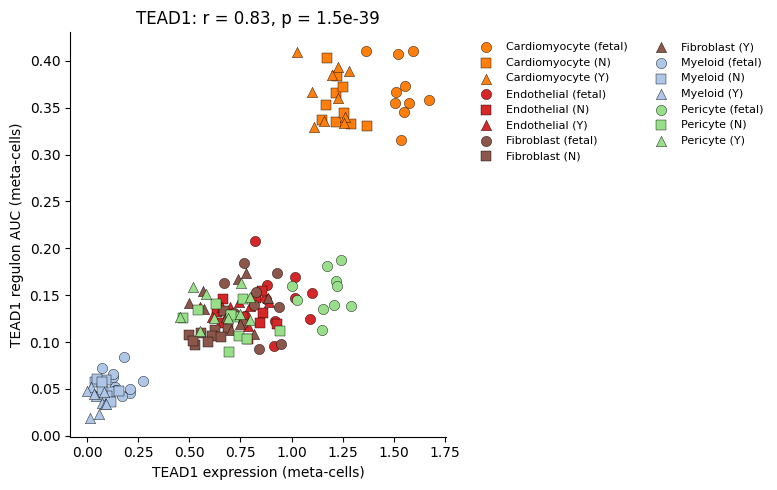

In [37]:
%%time
res = correlate_tf_expression_with_regulon_auc(
    TF="TEAD1",
    filt_AUC_df=filt_AUC_df,
    RNA_adata=RNA_adata, plot=True
)

#### Iterate through all TFs and calculate the correlations

In [38]:
len(filt_AUC_df.columns)

130

In [39]:
%%time

results = []

# use the TF names 
TFs = reg_info['TF']

# iterate through all TFs
for TF in TFs:
    try:
        res = correlate_tf_expression_with_regulon_auc(TF=TF, filt_AUC_df=filt_AUC_df, RNA_adata=RNA_adata, plot=False)
        results.append(res)
        print(f"{TF} (r={res['r']:.2f})")
    except ValueError as e:
        print(f"Error -- skipping {TF}: {e}")

ADNP (r=0.06)
SOX13 (r=0.67)
SMARCC1 (r=0.31)
SMAD3 (r=0.75)
SMAD2 (r=0.05)
SMAD1 (r=0.76)
RUNX2 (r=0.31)
RUNX1 (r=0.94)
RCOR1 (r=0.26)
RARB (r=0.91)
RAD21 (r=0.40)
POU2F1 (r=0.23)
PLAGL1 (r=0.78)
PGR (r=0.89)
PDLIM5 (r=0.96)
PBX1 (r=0.91)
NR6A1 (r=0.83)
NR3C2 (r=0.80)
NR2F2 (r=0.75)
NFYC (r=0.91)
NFIX (r=0.80)
NFIC (r=0.59)
NFIB (r=0.79)
NFIA (r=0.85)
SOX18 (r=0.91)
SOX4 (r=0.76)
SOX5 (r=0.76)
SOX6 (r=0.87)
ZNF90 (r=0.51)
ZNF846 (r=0.77)
ZNF704 (r=0.86)
ZNF680 (r=0.83)
ZNF565 (r=0.08)
ZNF423 (r=0.80)
ZNF385D (r=0.73)
ZNF33A (r=0.25)
ZEB1 (r=0.83)
ZBTB20 (r=0.73)
ZBTB16 (r=0.81)
NFE2L3 (r=0.85)
UBE2K (r=0.20)
TFDP1 (r=0.12)
TEAD4 (r=0.85)
TEAD1 (r=0.83)
TCF4 (r=0.86)
TCF21 (r=0.89)
TBX5 (r=0.97)
TBX2 (r=0.77)
TBX20 (r=0.74)
SPI1 (r=0.95)
SP3 (r=0.40)
SOX7 (r=0.86)
TFEC (r=0.94)
NFATC2 (r=0.81)
TFDP2 (r=0.75)
MTA3 (r=0.36)
FLI1 (r=0.96)
ETV6 (r=0.89)
ETV1 (r=0.85)
ETS1 (r=0.90)
ERG (r=0.96)
ELK3 (r=0.91)
ELF1 (r=0.74)
EBF3 (r=0.87)
EBF2 (r=0.90)
EBF1 (r=0.87)
E2F7 (r=0.51)
E2F3 (r=0.28)

In [14]:
# save the correlations 
corr_df = pd.DataFrame([
    {
        "TF": r["TF"],
        "regulon": r["regulon"],
        "r": r["r"],
        "p": r["p"]
    }
    for r in results
])

In [15]:
print(corr_df[corr_df['r'] < 0.7].shape)
print(corr_df[corr_df['r'] > 0.7].shape)

(40, 4)
(90, 4)


In [16]:
high_quality_regulon_df = corr_df[corr_df['r'] > 0.7]
high_quality_regulon_df.to_csv("04B_high_quality_regulon_df.csv")

Visualize some examples

CPU times: user 664 ms, sys: 464 ms, total: 1.13 s
Wall time: 734 ms


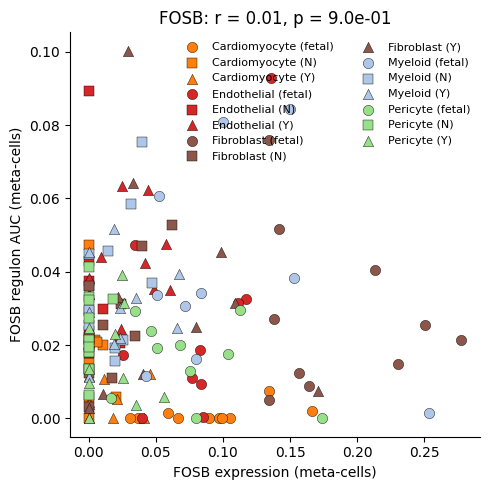

In [27]:
%%time

# low correlation example
res = correlate_tf_expression_with_regulon_auc(
    TF="FOSB",
    filt_AUC_df=filt_AUC_df,
    RNA_adata=RNA_adata
)

res['fig'].savefig(plots_dir + "FOSB_metacell_TF_regulon_corr.pdf")

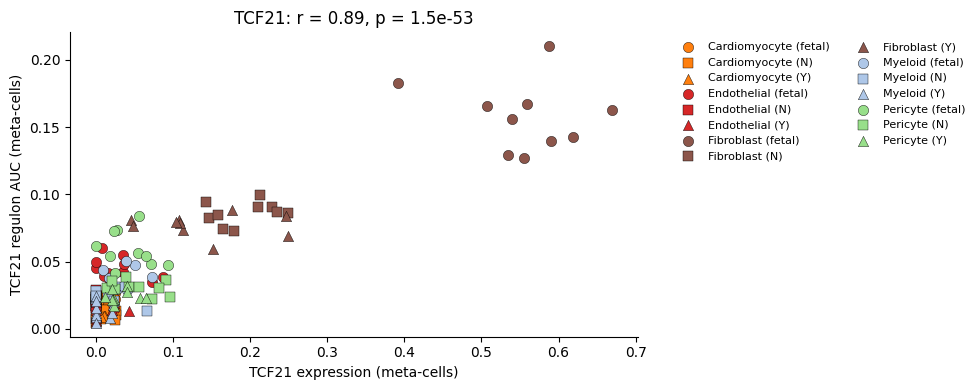

In [42]:
# high correlation example
res = correlate_tf_expression_with_regulon_auc(
    TF="TCF21",
    filt_AUC_df=filt_AUC_df,
    RNA_adata=RNA_adata, figsize=(10, 4)
)

res['fig'].savefig(plots_dir + "TCF_metacell_TF_regulon_corr.pdf")